<a href="https://colab.research.google.com/github/nrannisak2/Solute-Transport/blob/main/e1_solute_data_processing_plynlimon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1: Processing solute data

Goal: get familiar with typical operations that are useful for data visualization

## The data

We will use the [Plynlimon research catchment hydrochemistry](https://doi.org/10.5285/44095e17-43b0-45d4-a781-aab4f72da025) published by Neal, Kirchner, and Reynolds (2013) and previously described in Neal et al. ([2011](https://doi.org/10.1002/hyp.8191)). The data are part of a large data collection from the [Plynlimon experimental watersheds](https://www.ceh.ac.uk/our-science/monitoring-sites/plynlimon-research-catchments) (UK), which have been studied for years and have led to tens of scientific papers.

The hydrochemistry data files include:

- **supporting-documents**, with several metadata files describing the sites, the field and analytical methods, and with a full description of the measured variables.

- **data/PlynlimonResearchCatchmentHydrochemistryData.csv**, which is a data table with the measured hydrochemistry at the different sites collected approximately at weekly frequency. The data table has 15661 rows and 143 columns. All column names with "RDA" include the raw data version of the measurements.

In [ ]:
# Load the main packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

### Data import

In [ ]:
# Import the data into a Pandas DataFrame
from google.colab import drive
drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/PlynlimonResearchCatchmentHydrochemistryData.csv"
df = pd.read_csv(data_path)

# Since the variable "date_time" is not automatically recognised as
# date, let's force it to be a pd datetime object
df["date_time"] = pd.to_datetime(df["date_time"])

df.head()  # show the first 5 rows of the dataframe

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,SAMPLE,LOCATION,SITE NAME,date_time,Volume-weighted mean sampling time,Date,Yr,Month,Day,Time,...,Stream flow (Cumecs) RDA,Rainfall (mm) RDA,Cloud catch g RDA,Ground Water m RDA,Throughfall mm RDA,Temperature Deg C RDA,Time RDA,NOTES,type,DESCRIPTION
0,15092.0,A,Lower Hore,1983-05-10 12:00:00,1983/05/10 12:00,1983/05/10,1983,5,10,12:00 PM,...,0.063441,NaN,NaN,NaN,NaN,NaN,12:00:00 PM,NaN,stream,Main Hore stream channel above lower flume
1,15046.0,A,Lower Hore,1983-05-16 12:00:00,1983/05/16 12:00,1983/05/16,1983,5,16,12:00 PM,...,0.112784,NaN,NaN,NaN,NaN,NaN,12:00:00 PM,NaN,stream,Main Hore stream channel above lower flume
2,15047.0,A,Lower Hore,1983-05-25 12:00:00,1983/05/25 12:00,1983/05/25,1983,5,25,12:00 PM,...,0.077539,NaN,NaN,NaN,NaN,NaN,12:00:00 PM,NaN,stream,Main Hore stream channel above lower flume
3,15048.0,A,Lower Hore,1983-06-01 12:00:00,1983/06/01 12:00,1983/06/01,1983,6,1,12:00 PM,...,0.045818,NaN,NaN,NaN,NaN,NaN,12:00:00 PM,NaN,stream,Main Hore stream channel above lower flume
4,15049.0,A,Lower Hore,1983-06-07 11:00:00,1983/06/07 11:00,1983/06/07,1983,6,7,11:00 AM,...,0.038769,NaN,NaN,NaN,NaN,NaN,11:00:00 AM,NaN,stream,Main Hore stream channel above lower flume


In [ ]:
# Make a selection of variables and sites -> create subset from the database to play with
var_selection = [
    "SITE NAME",  # for the location
    "date_time",  # for the time
    "Cl mg/l",   # element of interest
    "Na mg/l",  # element of interest
    "log_flow",
    "Si mg/l",
    ]  # selection of variables

# Create a boolean index to filter by location and time -> query that is boolean index
q = (
    (df["SITE NAME"].isin(["Lower Hafren","Upper Hafren"])) &  # select 2 sites, give a true only for these 2 elements (other will receive false), & gives out other requirement
    (df["date_time"] >= '1995-01-01') & (df["date_time"] < '1995-03-01')  # select a temporal interval
)

# Produce the new dataframe (subset using the loc method)
df1 = df.loc[q,var_selection] # rows for which q is true, end up with db with site names
df1  # show the dataframe

,SITE NAME,date_time,Cl mg/l,Na mg/l,log_flow,Si mg/l
3770,Lower Hafren,1995-01-03 10:25:00,6.5,3.98,-0.774691,1.85
3771,Lower Hafren,1995-01-10 09:30:00,7.5,4.49,-0.368556,1.40
3772,Lower Hafren,1995-01-17 09:18:00,6.9,4.18,-0.546682,1.70
3773,Lower Hafren,1995-01-24 09:30:00,8.7,4.54,-0.473661,1.45
3774,Lower Hafren,1995-01-31 10:00:00,7.3,3.85,-0.239577,1.30
3775,Lower Hafren,1995-02-07 10:10:00,6.7,4.11,-0.707744,1.80
3776,Lower Hafren,1995-02-14 09:15:00,6.4,3.75,-0.277366,1.35
3777,Lower Hafren,1995-02-21 09:45:00,7.7,3.98,-0.180456,1.00
3778,Lower Hafren,1995-02-28 09:15:00,7.1,4.12,-0.552842,1.35
9742,Upper Hafren,1995-01-03 11:35:00,5.4,3.44,-0.708195,1.85


### Exercise #1

We want to explore linear relationships across a selection of measurements. We want to do this separately for the Upper and Lower Hafren sites.

You are free to select your measurements of interest. Make sure you include at least: "Cl mg/l", "Na mg/l", "Si mg/l", "log_flow"   

To display variables in pairs it is very convenient to use the `sns.pairplot` ([documentation](https://seaborn.pydata.org/generated/seaborn.pairplot.html)).

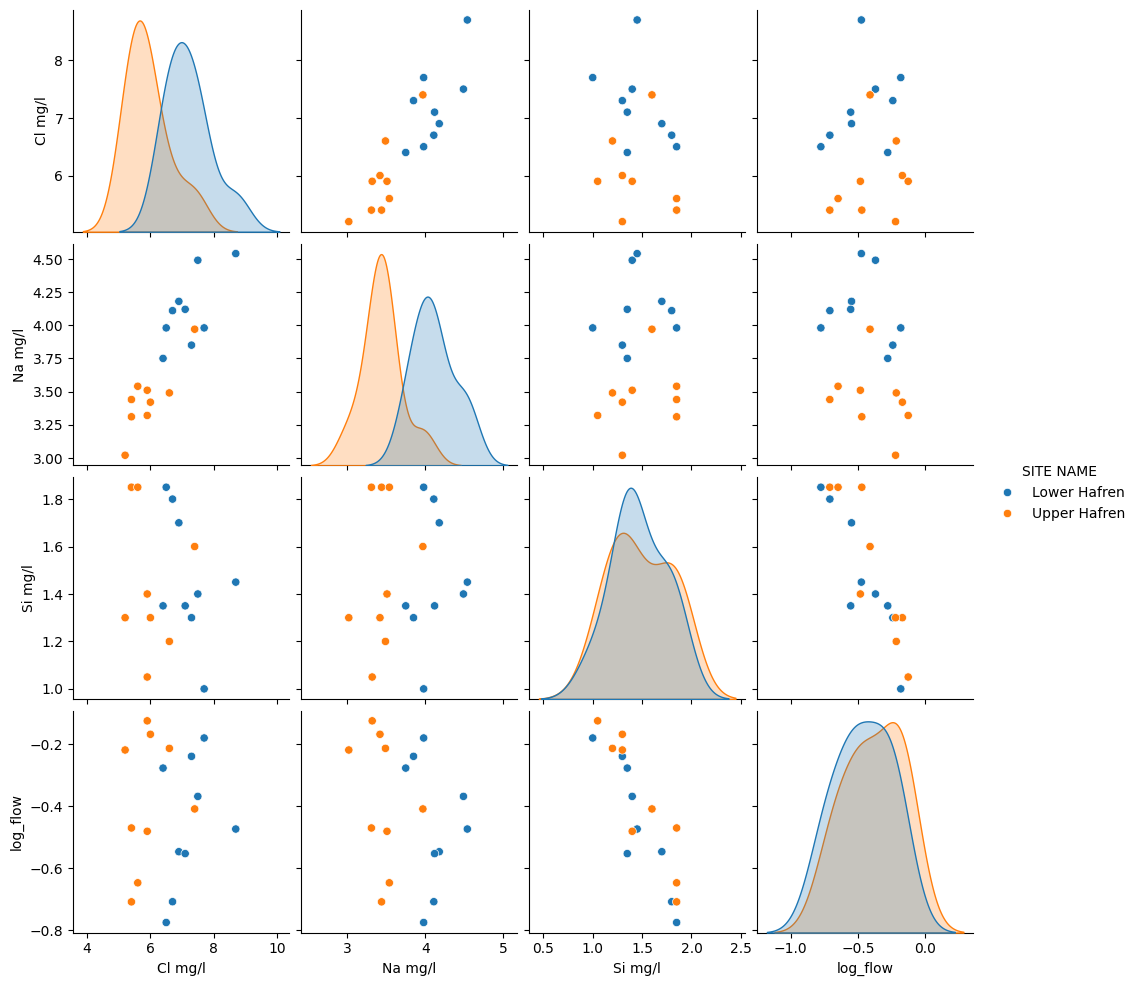

In [ ]:
# Do a lineplot to map 3 variables into the main aesthetics (x axis, y axis and color)
g = sns.pairplot(
    data=df1,
    vars = ["Cl mg/l",
            "Na mg/l",
            "Si mg/l",
            "log_flow"],
    hue="SITE NAME"
    )

plt.xticks(rotation=20)  # to avoid overlapping of the labels
plt.show()


### Exercise #2

We want to visualize different variables in a timeseries. As usual, we want to do this separately for the Upper and Lower Hafren sites.

Again, you are free to select your measurements of interest. Make sure you include at least: "Cl mg/l", "Na mg/l", "Si mg/l", "log_flow"   

To display multiple variables automatically in one plot, you will need to reshape the dataset to make it longer.

To display different timeseries in different *facets* (i.e. different panels), it is convenient to use the `sns.relplot` ([documentation](https://seaborn.pydata.org/generated/seaborn.relplot.html)). With the relplot you can build a grid in the figure and map variables to the rows and columns of such grid. When doing this, it is good to avoid sharing the same y-axis across subplots, because different measurements have different scales. To do so, you can pass the argument `facet_kws={'sharey': False, 'sharex': True}` to the plot function.

In [ ]:
# load current database, add month variable, simplify datatime
df1["month"] = df1["date_time"].dt.month
df1["date_time"] = df1["date_time"].dt.round('d')
df1.head()

# make the table longer through melt() function
df1_long = pd.melt(
    df1,
    id_vars = ["SITE NAME", "date_time", "month"],
    value_vars = ['Cl mg/l', 'Na mg/l', 'Si mg/l', 'log_flow']
)

# print the dataframe size
print("dataframe shape:", {df1_long.shape})
df1_long.head()

dataframe shape: {(72, 5)}


,SITE NAME,date_time,month,variable,value
0,Lower Hafren,1995-01-03,1,Cl mg/l,6.5
1,Lower Hafren,1995-01-10,1,Cl mg/l,7.5
2,Lower Hafren,1995-01-17,1,Cl mg/l,6.9
3,Lower Hafren,1995-01-24,1,Cl mg/l,8.7
4,Lower Hafren,1995-01-31,1,Cl mg/l,7.3


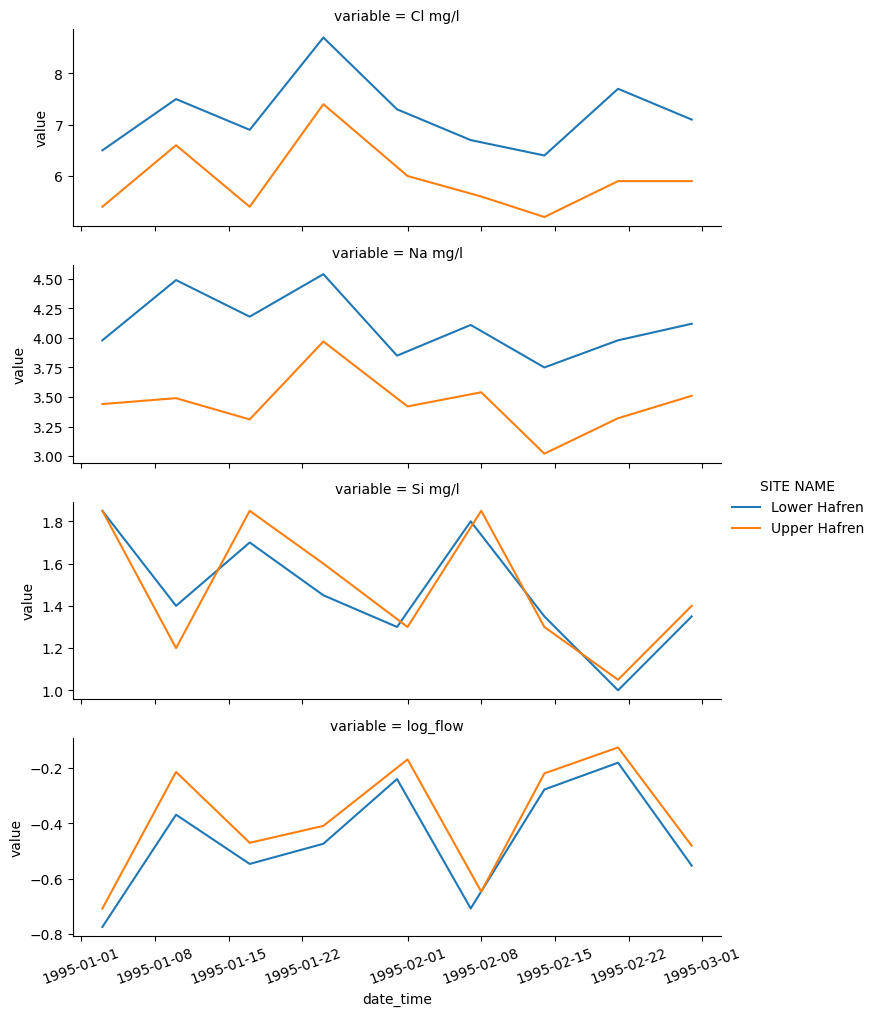

In [ ]:
# display different timeseries in different panels using the sns.relplot
g = sns.relplot(
    data=df1_long,
    x="date_time",
    y="value",
    row="variable", # one row of panels per measurement
    hue="SITE NAME",
    kind="line",
    facet_kws={'sharey': False, 'sharex':True},
    height=2.5,
    aspect=3
    )

plt.xticks(rotation=20)
plt.show()

### Exercise #3

We want to explore the presence of seasonal cycles in the measurements. To do so, we want to compute long-term mean monthly values. As in the previous exercises, we want to do this separately for the Upper and Lower Hafren sites.

They key point here is to make the table longer and group the dataset by site, variable and month (need to select or create a `month` variable for this). As in the previous exercise, you can display the results using a `sns.relplot`.

In [ ]:
# Compute long-term mean monthly values
# group by site, variable and month
monthly_means = (
    df1_long
    .groupby(["SITE NAME", "variable", "month"])["value"]
    .mean()
    .reset_index()
)

monthly_means.head()

,SITE NAME,variable,month,value
0,Lower Hafren,Cl mg/l,1,7.380
1,Lower Hafren,Cl mg/l,2,6.975
2,Lower Hafren,Na mg/l,1,4.208
3,Lower Hafren,Na mg/l,2,3.990
4,Lower Hafren,Si mg/l,1,1.540


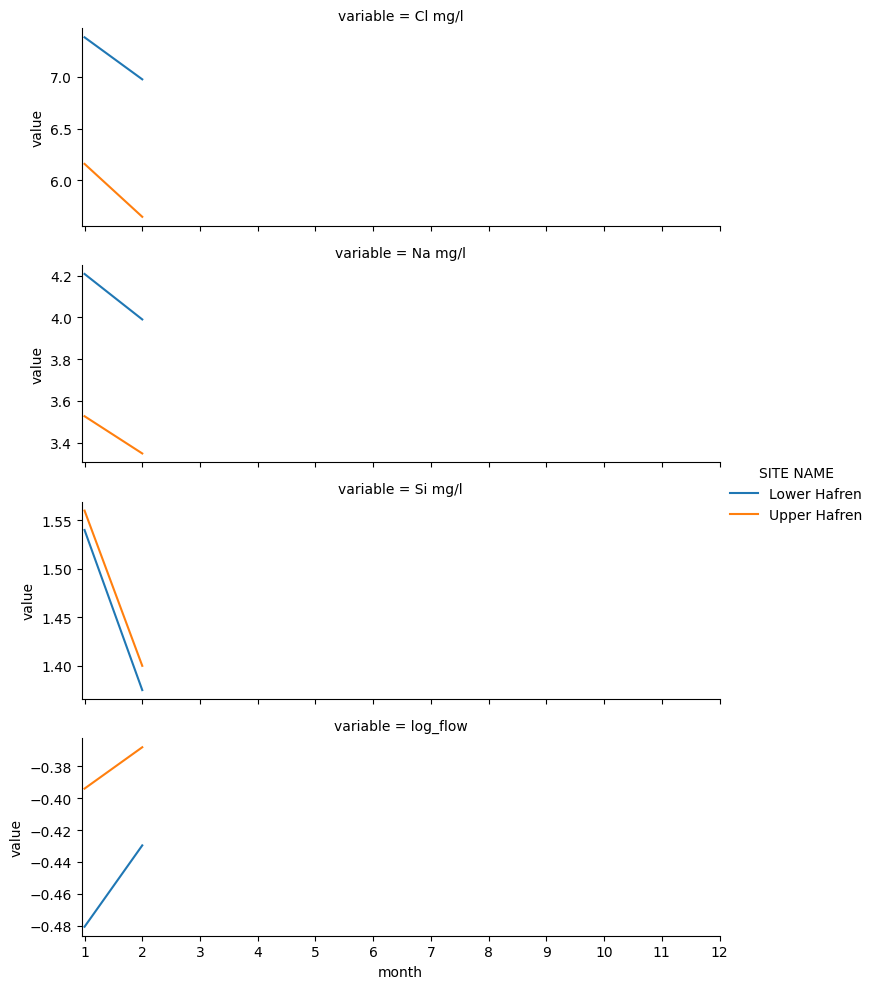

In [ ]:
# display the results using a sns.relplot

g = sns.relplot(
    data=monthly_means,
    x="month",
    y="value",
    row="variable", # one row of panels per measurement
    hue="SITE NAME",
    kind="line",
    facet_kws={'sharey': False, 'sharex':True},
    height=2.5,
    aspect=3
    )

g.set(xticks=range(1, 13))
plt.show()